# 🛒 End-to-End Pipeline: Khai thác Tập phổ biến (Apriori)
**Môn học:** Khai thác dữ liệu và ứng dụng (Data Mining)  
**Thực hiện:** Nhóm 4

**Tóm tắt Pipeline:**
1. **Chương 1 & 2:** Khởi tạo dữ liệu và mô phỏng thuật toán cơ bản.
2. **Chương 3:** Demo quá trình cài đặt thuật toán tối ưu.
3. **Chương 4:** Thực nghiệm Benchmark và trực quan hóa hiệu năng.
4. **Chương 5:** (Optional) Ứng dụng khai thác Luật kết hợp.

**Import thư viện**

In [8]:
import os
import sys
from IPython.display import display, Markdown, Image

# Thêm đường dẫn gốc để gọi được code từ thư mục src/
sys.path.insert(0, os.path.abspath('.'))

from src.algorithm.apriori import apriori
from src.utils import load_transactions_spmf, print_results

print("✅ Đã load xong các module cần thiết!")

✅ Đã load xong các module cần thiết!


#### **Hiểu về Dữ liệu và Thuật toán (Chương 1 & 2)**
Chúng ta sẽ bắt đầu bằng cách mô phỏng thuật toán trên một tập dữ liệu nhỏ (`toy1.txt`) để kiểm chứng tính đúng đắn theo các bước tính toán thủ công.

In [9]:
# Tải và hiển thị dữ liệu gốc
file_path = "data/toy/toy1.txt"
transactions = load_transactions_spmf(file_path)

display(Markdown(f"**Số lượng giao dịch (N):** {len(transactions)}"))
display(Markdown("**Các giao dịch mẫu:**"))
for i, t in enumerate(transactions):
    print(f"T{i+1}: {set(t)}")

**Số lượng giao dịch (N):** 5

**Các giao dịch mẫu:**

T1: {1, 3, 4}
T2: {2, 3, 5}
T3: {1, 2, 3, 5}
T4: {2, 5}
T5: {1, 2, 3, 4, 5}


#### **Cài đặt Thuật toán (Chương 3)**
Chạy thuật toán Apriori với tham số `min_support = 0.4` (tương đương support tuyệt đối = 2). 
*Điểm nhấn:* Thuật toán sử dụng **Bitarray** để tối ưu hóa quá trình đếm support.

In [10]:
import time

start_time = time.time()
# Chạy thuật toán
frequent_itemsets = apriori(transactions, min_support=0.4, use_bitarray=True)
end_time = time.time()

display(Markdown(f"**Thời gian thực thi:** `{end_time - start_time:.5f} giây`"))
print_results(frequent_itemsets, len(transactions))

**Thời gian thực thi:** `0.00100 giây`


  FREQUENT ITEMSET MINING RESULTS
  Total frequent itemsets: 19
  Total transactions: 5


--- 1-itemsets (5 sets) ---
  {1}                             sup = 3 (60.00%)
  {2}                             sup = 4 (80.00%)
  {3}                             sup = 4 (80.00%)
  {4}                             sup = 2 (40.00%)
  {5}                             sup = 4 (80.00%)

--- 2-itemsets (8 sets) ---
  {1, 2}                          sup = 2 (40.00%)
  {1, 3}                          sup = 3 (60.00%)
  {1, 4}                          sup = 2 (40.00%)
  {1, 5}                          sup = 2 (40.00%)
  {2, 3}                          sup = 3 (60.00%)
  {2, 5}                          sup = 4 (80.00%)
  {3, 4}                          sup = 2 (40.00%)
  {3, 5}                          sup = 3 (60.00%)

--- 3-itemsets (5 sets) ---
  {1, 2, 3}                       sup = 2 (40.00%)
  {1, 2, 5}                       sup = 2 (40.00%)
  {1, 3, 4}                       sup = 2 (40.00%)
  {1, 3

#### **Thực nghiệm và Đánh giá (Chương 4)**
Để đánh giá hiệu năng trên dữ liệu thực tế (Chess, Mushroom, Retail), chúng ta đã xây dựng module kiểm thử tự động `test_benchmark.py`. Dưới đây là các kết quả trực quan hóa.

### 1. Đánh giá Khả năng mở rộng (Scalability)

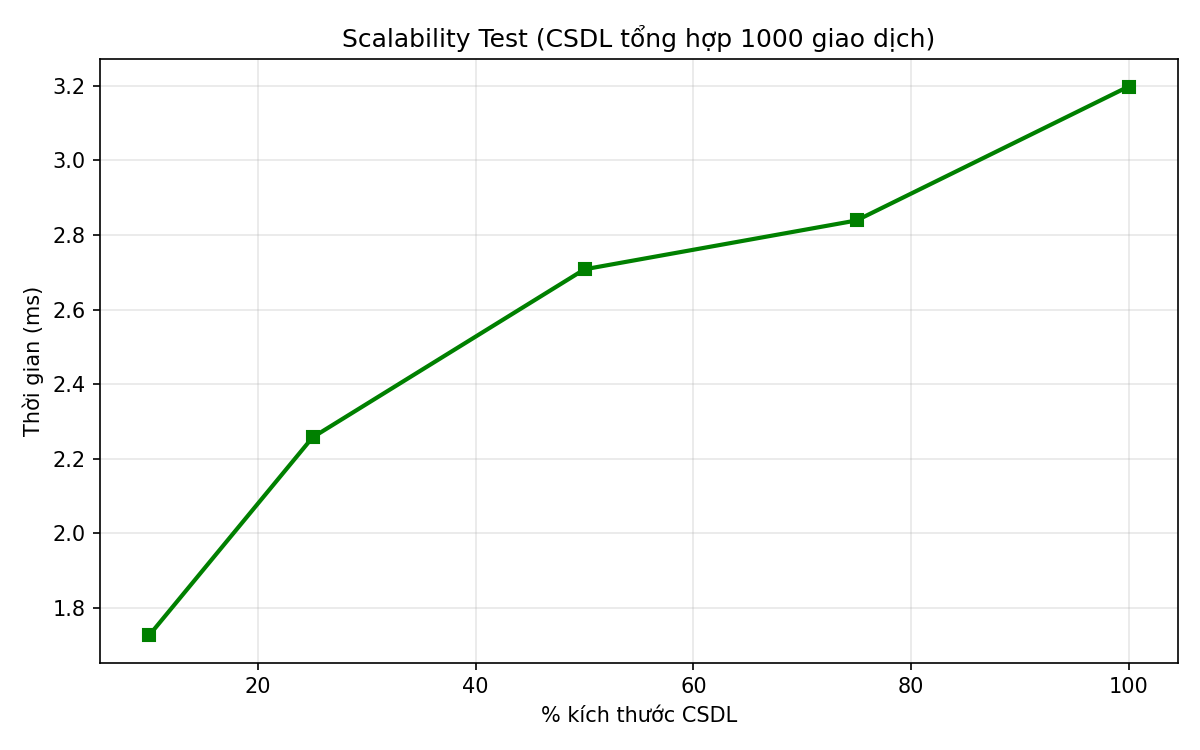

### 2. Đánh giá Thời gian chạy theo Min Support

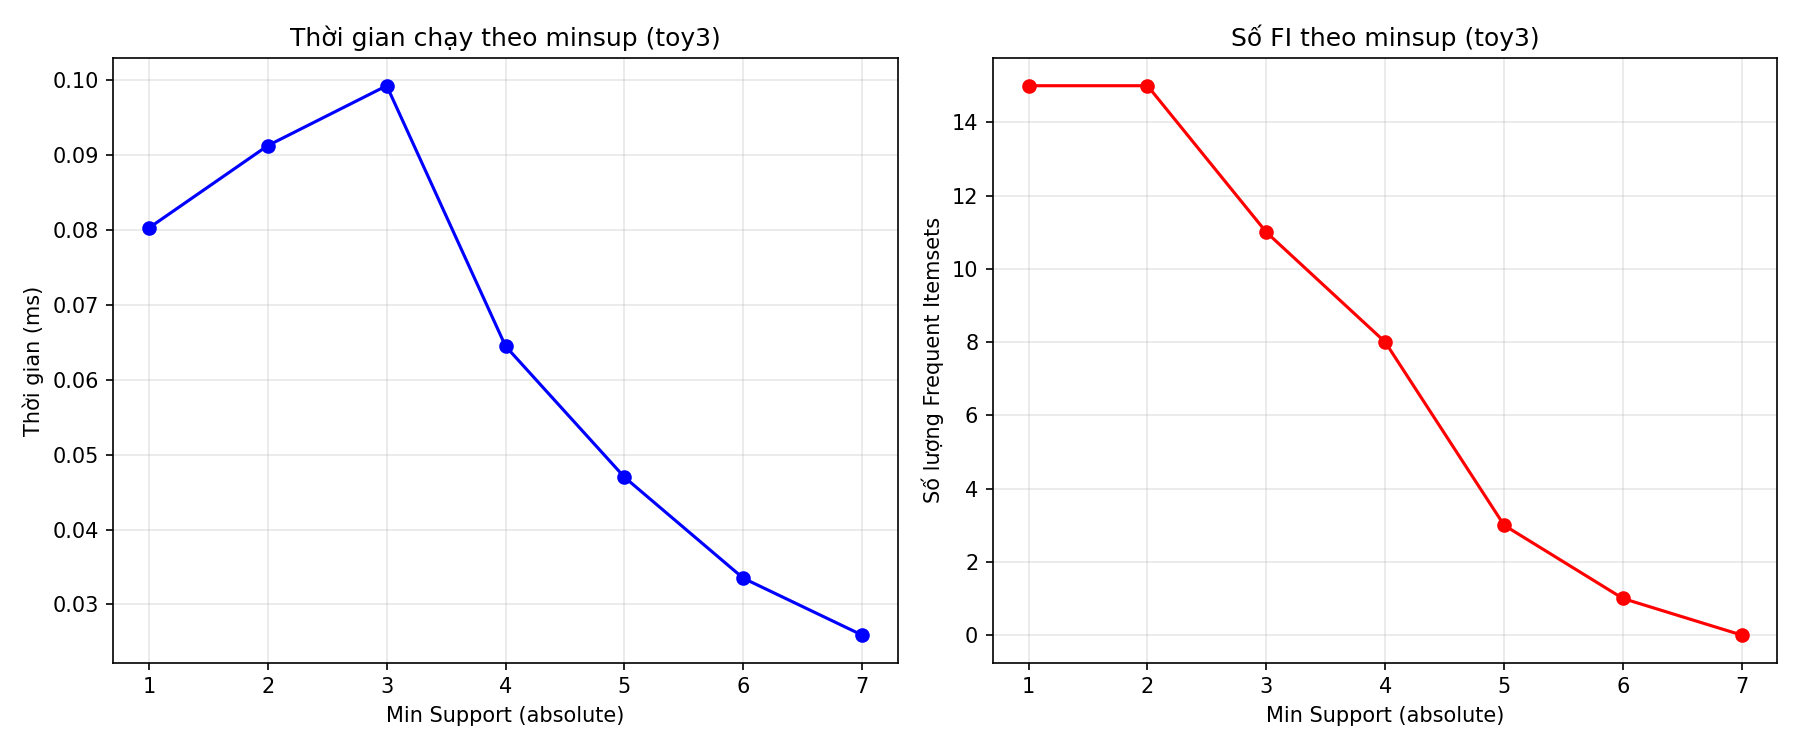

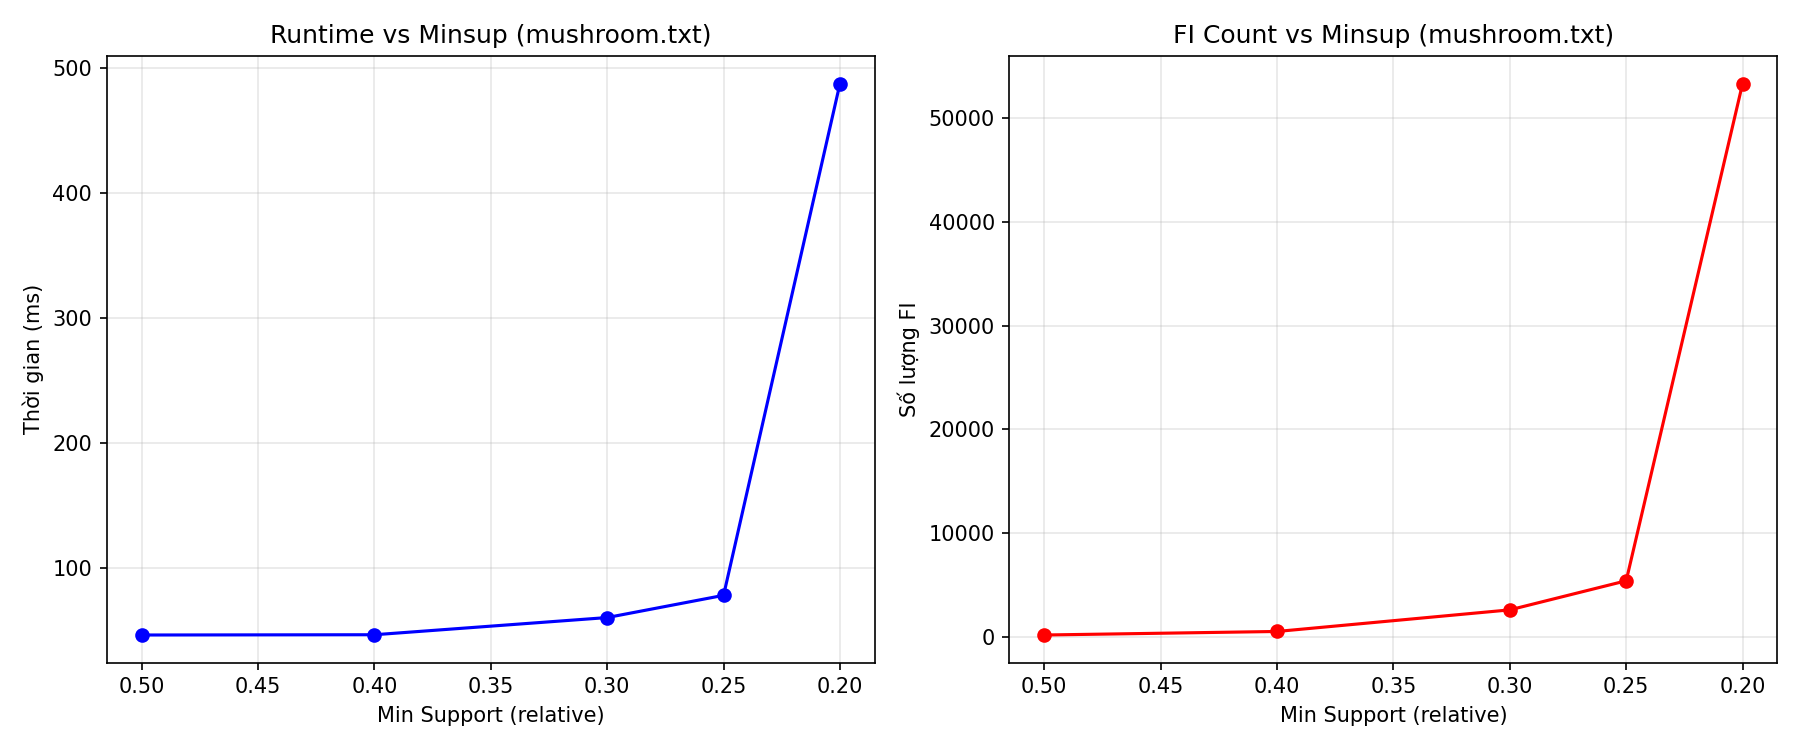

In [16]:
display(Markdown("### 1. Đánh giá Khả năng mở rộng (Scalability)"))
display(Image(filename='docs/scalability_synthetic.png'))

display(Markdown("### 2. Đánh giá Thời gian chạy theo Min Support"))
display(Image(filename='docs/runtime_vs_minsup_toy3.png'))

display(Image(filename='docs/benchmark_mushroom.png'))

#### **Khối 4: Ứng dụng Thực tế (Chương 5 - Optional)**
*(Nếu nhóm bạn có làm phần Luật kết hợp, bạn ghi thêm phần giải thích vào đây. Nếu không, bạn có thể xóa toàn bộ Khối 4 này).*

In [15]:
# Demo sinh luật kết hợp với Confidence >= 60%
# rules = generate_rules(frequent_itemsets, min_confidence=0.6)
# display(rules)